# Análisis de Distancias de Enlace — Simulación de Dinámica Molecular

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS · `gmx distance`  
**Temperaturas simuladas:** 298 K y 400 K

**Enlaces analizados:**

| Etiqueta (`distances.ndx`) | Átomos | Descripción |
|---|---|---|
| `CO-ALA-2` | 15 – 16 | Enlace C=O (carbonilo, ALA-2) |
| `CACB-ARG-3` | 19 – 21 | Enlace Cα–Cβ (ARG-3) |

Las secciones 3–4 muestran la evolución temporal de ambos enlaces a las dos temperaturas, separados por tipo de enlace.  
La sección 5 recoge la comparativa estadística completa de **ambos enlaces**.

---


## 1. Importación de librerías y configuración de estilo

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import sem, norm

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.linewidth':      1.2,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.1,
    'ytick.major.width':   1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha':   0.9,
    'legend.fontsize':     10,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# Columnas: tiempo (ps), distancia (nm)
COLS = ['time_ps', 'd_nm']

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 2. Carga de datos

In [10]:
def load_xvg(filepath, col_names):
    """Lee un archivo .xvg de GROMACS ignorando cabeceras (líneas con '@' o '#')."""
    data = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            data.append(list(map(float, line.split())))
    df = pd.DataFrame(data, columns=col_names)
    return df

# ── C=O (ALA-2)  átomos 15–16 ─────────────────────────────────────────────────
df_CO_298  = load_xvg('dist-CO-ALA-2-298.xvg',  COLS)
df_CO_400  = load_xvg('dist-CO-ALA-2-400.xvg',  COLS)

# ── Cα–Cβ (ARG-3)  átomos 19–21 ───────────────────────────────────────────────
df_CACB_298 = load_xvg('dist-CACB-ARG-3-298.xvg', COLS)
df_CACB_400 = load_xvg('dist-CACB-ARG-3-400.xvg', COLS)

# Alias usados en secciones 4-10 (Cα–Cβ)
df_298 = df_CACB_298
df_400 = df_CACB_400
BOND_LABEL = r'$\mathrm{C}_\alpha\!-\!\mathrm{C}_\beta$ (ARG-3)'

# nm → Å en todos los DataFrames
for df in [df_CO_298, df_CO_400, df_CACB_298, df_CACB_400]:
    df['d_A'] = df['d_nm'] * 10

print('Archivos cargados:')
print(f'  C=O  (ALA-2)  298 K → {len(df_CO_298)} frames, '
      f't = {df_CO_298.time_ps.min():.3f} – {df_CO_298.time_ps.max():.3f} ps')
print(f'  C=O  (ALA-2)  400 K → {len(df_CO_400)} frames')
print(f'  CaCb (ARG-3)  298 K → {len(df_CACB_298)} frames')
print(f'  CaCb (ARG-3)  400 K → {len(df_CACB_400)} frames')
df_CACB_298.head(3)


Archivos cargados:
  C=O  (ALA-2)  298 K → 2001 frames, t = 0.000 – 2.000 ps
  C=O  (ALA-2)  400 K → 2001 frames
  CaCb (ARG-3)  298 K → 2001 frames
  CaCb (ARG-3)  400 K → 2001 frames


,time_ps,d_nm,d_A
0,0.000,0.152,1.52
1,0.001,0.152,1.52
2,0.002,0.152,1.52


## 3. Comparativa apilada — Cα–Cβ (ARG-3): 298 K vs 400 K

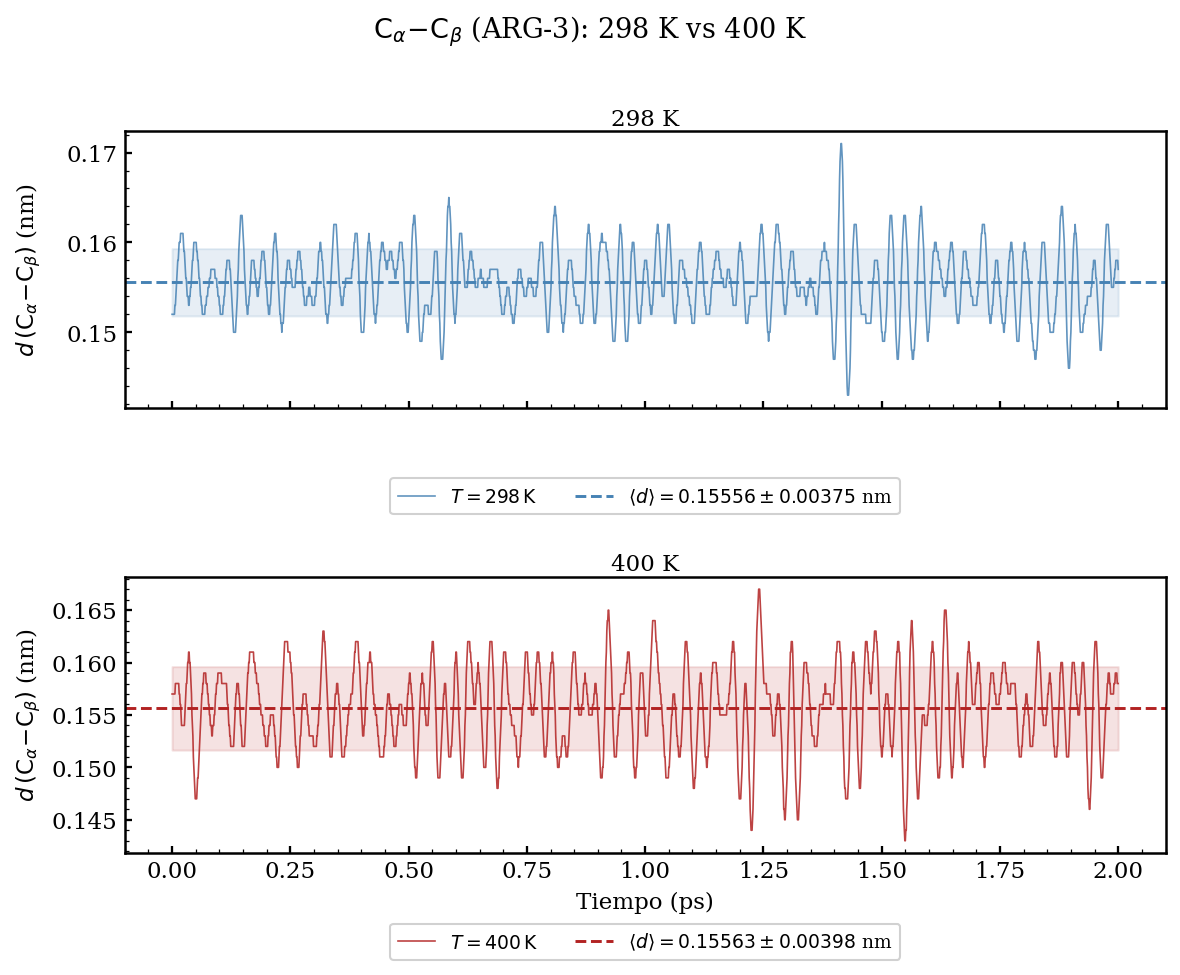

Figura guardada como dist_CACB_comparison_stacked.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

for ax, df, T, col in zip(axes,
                           [df_298, df_400],
                           ['298', '400'],
                           ['steelblue', 'firebrick']):
    mean_val = df['d_nm'].mean()
    std_val  = df['d_nm'].std()

    ax.plot(df['time_ps'], df['d_nm'],
            color=col, lw=0.8, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mean_val, color=col, lw=1.4, ls='--',
               label=rf'$\langle d \rangle = {mean_val:.5f} \pm {std_val:.5f}$ nm')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.13)

    ax.set_ylabel(r'$d\,(\mathrm{C}_\alpha\!-\!\mathrm{C}_\beta)$ (nm)', fontsize=11)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.set_title(f'{T} K', fontsize=11, pad=3)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)

axes[-1].set_xlabel('Tiempo (ps)', fontsize=11)
fig.suptitle(r'$\mathrm{C}_\alpha\!-\!\mathrm{C}_\beta$ (ARG-3): 298 K vs 400 K', fontsize=13, y=1.01)
fig.align_ylabels()

plt.tight_layout()
plt.savefig('dist_CACB_comparison_stacked.png')
plt.show()
print('Figura guardada como dist_CACB_comparison_stacked.png')


## 4. Comparativa apilada — C=O (ALA-2): 298 K vs 400 K


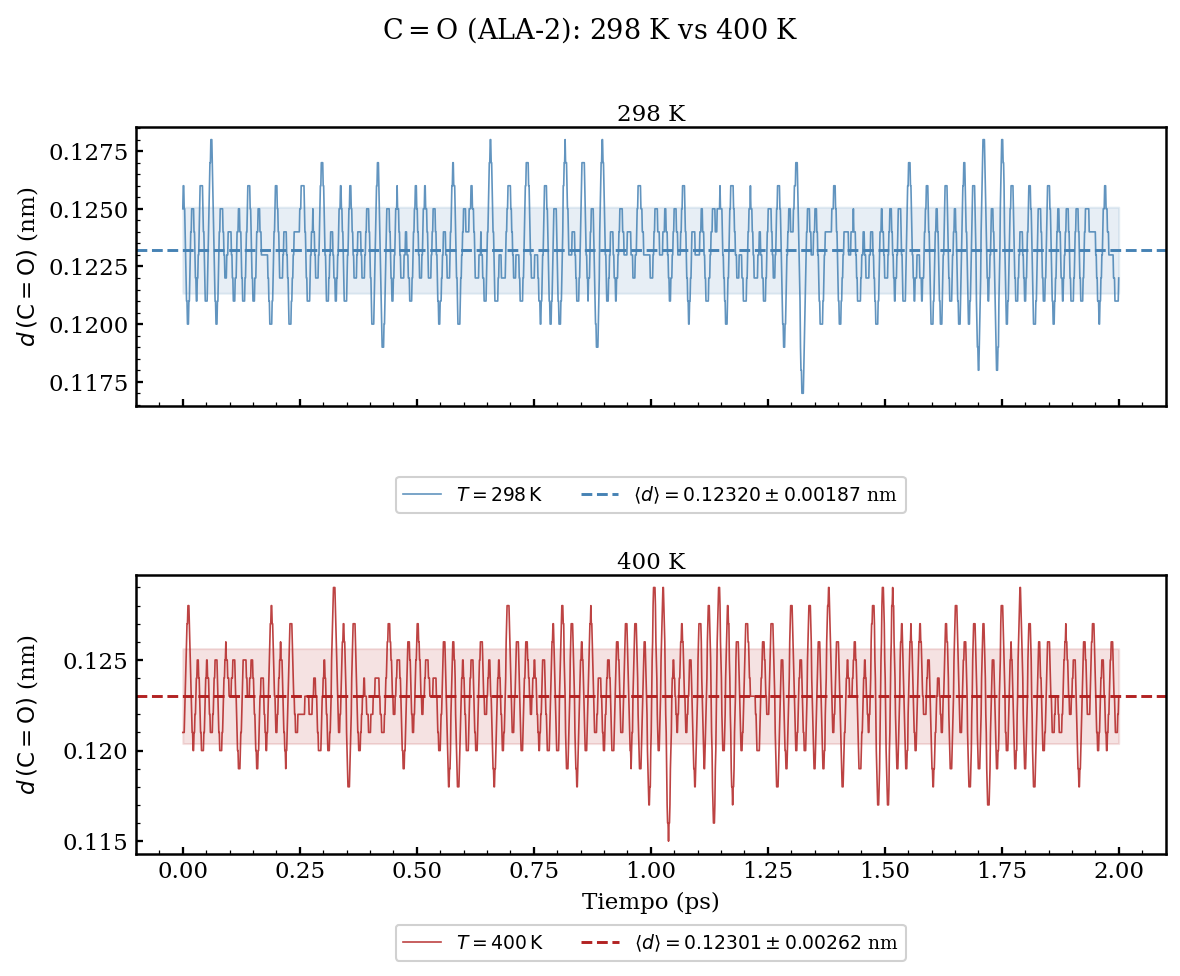

Figura guardada como dist_CO_comparison_stacked.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

for ax, df, T, col in zip(axes,
                           [df_CO_298, df_CO_400],
                           ['298', '400'],
                           ['steelblue', 'firebrick']):
    mean_val = df['d_nm'].mean()
    std_val  = df['d_nm'].std()

    ax.plot(df['time_ps'], df['d_nm'],
            color=col, lw=0.8, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mean_val, color=col, lw=1.4, ls='--',
               label=rf'$\langle d \rangle = {mean_val:.5f} \pm {std_val:.5f}$ nm')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.13)

    ax.set_ylabel(r'$d\,(\mathrm{C{=}O})$ (nm)', fontsize=11)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.set_title(f'{T} K', fontsize=11, pad=3)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)

axes[-1].set_xlabel('Tiempo (ps)', fontsize=11)
fig.suptitle(r'C$=$O (ALA-2): 298 K vs 400 K', fontsize=13, y=1.01)
fig.align_ylabels()

plt.tight_layout()
plt.savefig('dist_CO_comparison_stacked.png')
plt.show()
print('Figura guardada como dist_CO_comparison_stacked.png')


## 5. Comparación de distancias de enlace — ambos enlaces y temperaturas

Un mismo eje para los dos enlaces y las dos temperaturas.
**Color** → tipo de enlace · **Línea sólida** → 298 K · **Línea discontinua** → 400 K


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

series_config = [
    # (DataFrame,    color,       ls,   label)
    (df_CO_298,   'steelblue', '-',   r'298 K — C$=$O (ALA-2)'),
    (df_CO_400,   'steelblue', '--',  r'400 K — C$=$O (ALA-2)'),
    (df_CACB_298, 'seagreen',  '-',   r'298 K — C$_\alpha$–C$_\beta$ (ARG-3)'),
    (df_CACB_400, 'seagreen',  '--',  r'400 K — C$_\alpha$–C$_\beta$ (ARG-3)'),
]

for df, col, ls, label in series_config:
    ax.plot(df['time_ps'], df['d_nm'],
            color=col, ls=ls, lw=0.9, alpha=0.85, label=label)

ax.set_xlabel('Tiempo (ps)')
ax.set_ylabel('Distancia (nm)')
ax.set_title('Comparación de Distancias de Enlace')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('dist_both_bonds_combined.png')
plt.show()
print('Figura guardada como dist_both_bonds_combined.png')


## 5. Comparativa estadística — ambos enlaces (C=O y Cα–Cβ)

Resumen de los parámetros estadísticos obtenidos con `gmx distance` para los dos enlaces seleccionados a 298 K y 400 K.

In [13]:
bonds_data = {
    'C=O (ALA-2) — átomos 15–16': {
        298: df_CO_298['d_nm'],
        400: df_CO_400['d_nm'],
    },
    'Cα–Cβ (ARG-3) — átomos 19–21': {
        298: df_CACB_298['d_nm'],
        400: df_CACB_400['d_nm'],
    },
}

rows_bonds = []
for bond, temps in bonds_data.items():
    for T, series in temps.items():
        rows_bonds.append({
            'Enlace':     bond,
            'T (K)':      T,
            'N':          len(series),
            '⟨d⟩ (nm)':  round(series.mean(), 5),
            'σ(d) (nm)':  round(series.std(),  5),
            'SEM (nm)':   round(sem(series),    6),
            'Min (nm)':   round(series.min(),   5),
            'Max (nm)':   round(series.max(),   5),
            '⟨d⟩ (Å)':   round(series.mean() * 10, 4),
            'σ(d) (Å)':   round(series.std()  * 10, 4),
        })

bonds_df = pd.DataFrame(rows_bonds)

(bonds_df.style
    .format({
        '⟨d⟩ (nm)':  '{:.5f}',
        'σ(d) (nm)':  '{:.5f}',
        'SEM (nm)':   '{:.6f}',
        'Min (nm)':   '{:.5f}',
        'Max (nm)':   '{:.5f}',
        '⟨d⟩ (Å)':   '{:.4f}',
        'σ(d) (Å)':   '{:.4f}',
    })
    .set_caption('Tabla 1. Resumen estadístico de las distancias de enlace a 298 K y 400 K.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .apply(lambda col: [
        'background-color: #eaf4fb' if v == 298 else 'background-color: #fdecea'
        for v in col
    ], subset=['T (K)'])
    .hide(axis='index')
)

Enlace,T (K),N,⟨d⟩ (nm),σ(d) (nm),SEM (nm),Min (nm),Max (nm),⟨d⟩ (Å),σ(d) (Å)
C=O (ALA-2) — átomos 15–16,298,2001,0.12320,0.00187,0.000042,0.11700,0.12800,1.2320,0.0187
C=O (ALA-2) — átomos 15–16,400,2001,0.12301,0.00262,0.000059,0.11500,0.12900,1.2301,0.0262
Cα–Cβ (ARG-3) — átomos 19–21,298,2001,0.15556,0.00375,0.000084,0.14300,0.17100,1.5556,0.0375
Cα–Cβ (ARG-3) — átomos 19–21,400,2001,0.15563,0.00398,0.000089,0.14300,0.16700,1.5563,0.0398
